In [23]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()

cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df = pd.DataFrame(iris.data, columns= cols)
df['target'] = iris.target
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


<function matplotlib.pyplot.show(close=None, block=None)>

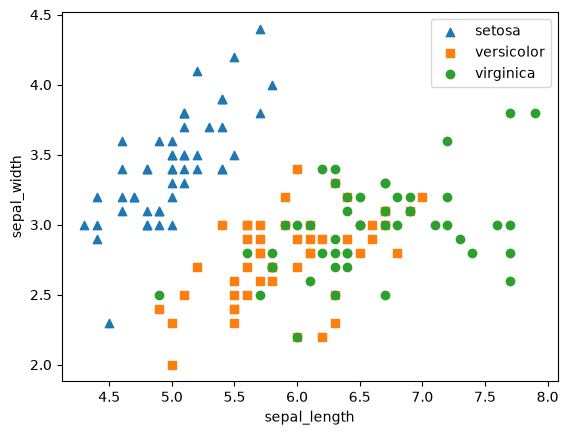

In [24]:
markers = ['^','s','o']

for i, marker in enumerate(markers):
    x_data = df[df['target']==i]['sepal_length']
    y_data = df[df['target']==i]['sepal_width']
    plt.scatter(x_data,y_data,marker = marker, label = iris.target_names[i])

plt.legend()
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.show

In [25]:
from sklearn.preprocessing import StandardScaler

iris_scaled = StandardScaler().fit_transform(df.iloc[:,:-1])

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)
print(iris_pca.shape)

(150, 2)


In [27]:
pca_cols = ['pca_1', 'pca_2']

df_pca = pd.DataFrame(iris_pca, columns=pca_cols)
df_pca['target'] = iris.target
df_pca.head()

,pca_1,pca_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


<function matplotlib.pyplot.show(close=None, block=None)>

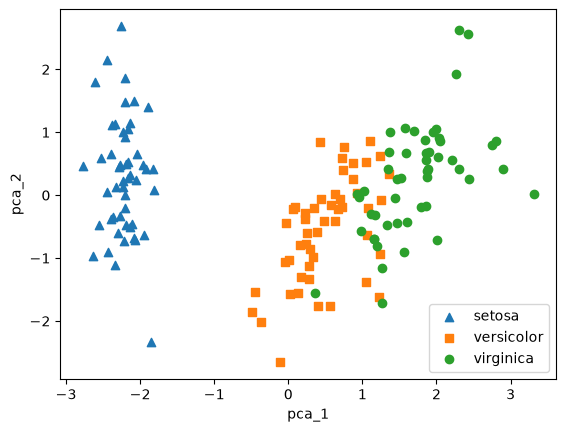

In [28]:
markers = ['^','s','o']

for i, marker in enumerate(markers):
    x_data = df_pca[df_pca['target']==i]['pca_1']
    y_data = df_pca[df_pca['target']==i]['pca_2']
    plt.scatter(x_data,y_data,marker = marker, label = iris.target_names[i])

plt.legend()
plt.xlabel('pca_1')
plt.ylabel('pca_2')
plt.show

In [29]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rfc = RandomForestClassifier(random_state=42)
scores = cross_val_score(rfc, iris.data, iris.target, 
                         scoring='accuracy',
                         cv=3)

print(scores)
print(np.mean(scores))

[0.98 0.94 0.98]
0.9666666666666667


In [31]:
pca_X = df_pca[['pca_1','pca_2']]
scores_pca = cross_val_score(rfc, pca_X, iris.target, 
                             scoring='accuracy',
                             cv=3)

print(scores_pca)
print(np.mean(scores_pca))

[0.88 0.88 0.9 ]
0.8866666666666667


In [32]:
import pandas as pd

df = pd.read_excel('../data/pca_credit_card.xls',
                   header=1,
                   sheet_name='Data').iloc[0:,1:]
print(df.shape)
df.head()

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [35]:
df = df.rename(columns={'PAY_0':'PAY_1', 'default payment next month':'default'})

In [37]:
y = df['default']
X = df.drop('default', axis=1)

<Axes: >

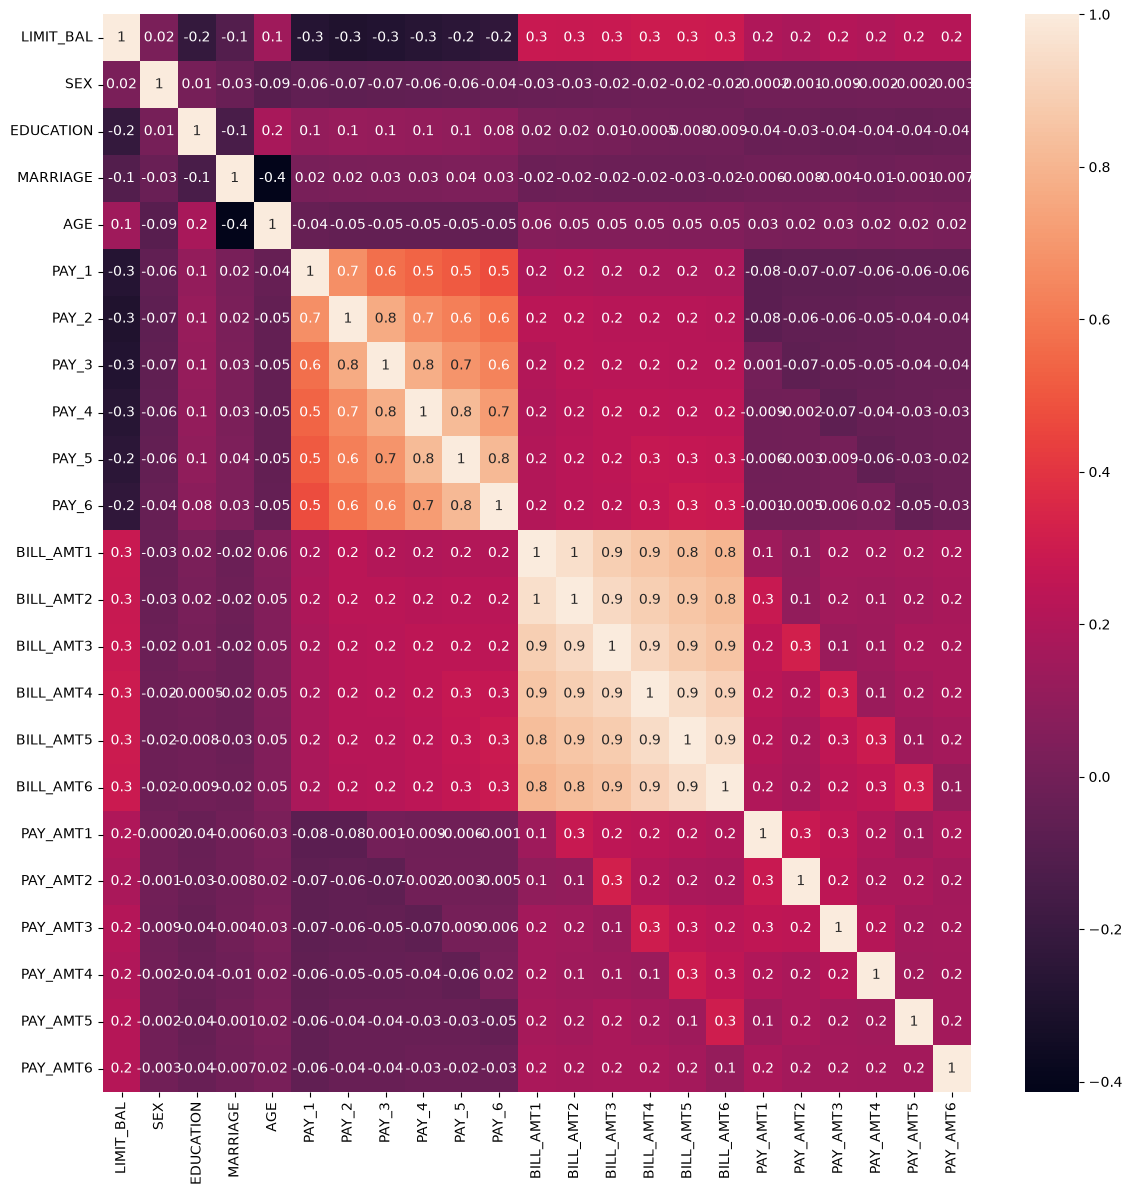

In [39]:
import seaborn as sns

corr = X.corr()
plt.figure(figsize=(14,14))
sns.heatmap(corr, annot=True, fmt='.1g')

In [46]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_bill = ['BILL_AMT' + str(i) for i in range(1, 7)]
cols_pay = ['PAY_' + str(i) for i in range(1, 7)]
cols_amt = ['PAY_AMT' + str(i) for i in range(1, 7)]

print(cols_bill)
cols_bill.extend(cols_pay)
cols_bill.extend(cols_amt)
print(cols_bill)

['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [49]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X[cols_bill])
X[cols_bill] = df_scaled
pca = PCA(n_components=2)
pca.fit(df_scaled)
print(pca.explained_variance_ratio_)

[0.36180187 0.20618472]


In [50]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rfc = RandomForestClassifier(n_estimators=500, random_state=42)
scores = cross_val_score(rfc, X, y, scoring= 'accuracy', cv=3)

print(scores)
print(np.mean(scores))

[0.8079 0.8204 0.823 ]
0.8170999999999999


In [51]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(X)

pca = PCA(n_components=6)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rfc, df_pca, y, scoring='accuracy', cv=3)

print(scores_pca)
print(np.mean(scores_pca))

[0.792  0.7987 0.8014]
0.7973666666666667


In [52]:
print(pca.explained_variance_ratio_)

[0.28448215 0.17818817 0.06743307 0.06401154 0.04457556 0.04161737]
